# EDA - Analisis Exploratorio de Datos
Proyecto: Recomendador de Cultivos California (TFM)
Fuentes: CDL/USDA + PRISM (historico) + NASA NEX-GDDP-CMIP6 (futuro) + gSSURGO (suelo)

In [33]:
# imports librerias
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import os
import sys

# Buscamos la raíz del proyecto
current_dir = os.path.abspath(os.getcwd())
while current_dir != os.path.dirname(current_dir):
    if "main.py" in os.listdir(current_dir):
        break
    current_dir = os.path.dirname(current_dir)

# Registramos la raíz exacta en el sistema de Python
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

#Llamamos las configuraciones de mongo
from src.config import MONGO_URI, DB_NAME, COLLECTION_NAME
from src.utils import TARGET_CROPS, HIST_CLIM_VARS 


In [2]:
# ── Configuracion visual ────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 130
OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches="tight")
    print(f"  [guardado] {path}")
    plt.close(fig)

In [4]:
# Conexión a MongoDB
client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION_NAME]

# traemos TODOS los documentos 
cursor = collection.find({}, {"_id": 0})
datos_lista = list(cursor)

df_raw = pl.DataFrame(datos_lista, infer_schema_length=None)

print(f"Dimensiones: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas.")

Dimensiones: 1109452 filas, 41 columnas.


# Overview del Dataset: Raw data

In [5]:
# Mostrar las primeras 5 filas
print("Primeras filas del dataset:")
display(df_raw.head())

Primeras filas del dataset:


year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,vpdmax,vpdmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ecec_r,ksat_r,om_r,pbray1_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,ptotal_r,sandtotal_r,silttotal_r,sumbases_r,es_proyeccion,hurs_245,hurs_585,pr_245,pr_585,referencia_base,tmax_245,tmax_585,tmean_245,tmean_585,tmin_245,tmin_585
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,null,f64,f64,f64,bool,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,22.509001,1.777,0.15,15.0,31.0,1.35,3.0,null,2.7,0.75,null,8.2,true,30.0,null,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,25.107,4.256,0.17,24.4,31.0,1.45,0.0,null,9.0,0.75,null,7.9,true,46.0,null,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,23.787001,2.398,0.16,48.5,59.299999,1.18,0.9,null,0.42,3.99,null,6.8,true,9.0,null,0.9,39.799999,45.0,null,null,null,null,null,null,null,null,null,null,null,null
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,25.513,4.177,0.11,7.5,15.0,1.55,1.0,null,28.0,0.75,null,7.9,true,28.0,null,65.900002,19.1,null,null,null,null,null,null,null,null,null,null,null,null,null
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,24.395,2.449,0.09,8.1,15.0,1.55,1.0,null,5.5,1.0,null,6.3,true,23.0,null,66.0,19.0,6.9,null,null,null,null,null,null,null,null,null,null,null,null


### Tipos de Datos

In [6]:
tabla_esquema = pl.DataFrame({
    "Columna": list(df_raw.schema.keys()),
    "Tipo de Dato": [str(dtype) for dtype in df_raw.schema.values()]
})

#visualizar
with pl.Config(tbl_rows=-1):
    display(tabla_esquema)

Columna,Tipo de Dato
str,str
"""year""","""Int64"""
"""crop_id""","""Int64"""
"""crop_name""","""String"""
"""is_target""","""Boolean"""
"""location""","""Struct({'type': String, 'coord…"
"""processed""","""Boolean"""
"""ppt""","""Float64"""
"""processed_climate""","""Boolean"""
"""tmax""","""Float64"""


# Análisis de Missing Values

In [7]:
# Calculamos el total de nulos por columna (mantiene los nombres originales de las variables)
total_nulos = df_raw.select(pl.all().null_count())

# Calculamos el porcentaje de nulos por columna
porcentaje_nulos = df_raw.select((pl.all().null_count() / pl.count() * 100).round(2))

# tabla nulos (Nombre | Total | %)
df_nulls = pl.DataFrame({
    "Variable": df_raw.columns,
    "Total Nulos": total_nulos.row(0),
    "% Nulos": porcentaje_nulos.row(0)
}).sort("Total Nulos", descending=True)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(df_nulls)

C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\3499373317.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  porcentaje_nulos = df_raw.select((pl.all().null_count() / pl.count() * 100).round(2))


Variable,Total Nulos,% Nulos
str,i64,f64
"""ptotal_r""",1109452,100.0
"""pbray1_r""",1109448,100.0
"""ecec_r""",1091224,98.36
"""es_proyeccion""",999452,90.09
"""hurs_245""",999452,90.09
"""hurs_585""",999452,90.09
"""pr_245""",999452,90.09
"""pr_585""",999452,90.09
"""referencia_base""",999452,90.09


## Tratamiento de Missing Values

In [8]:
# Creamos una copia del dataset y eliminamos las variables que venían totalmente vacías desde la fuente osea que el 100% de sus datos eran missing
df_imputed = df_raw.clone()
df_imputed = df_imputed.drop(["ptotal_r", "pbray1_r"])

En la revisión de nulos se puede ver que el dataset original tiene 9.91% de nulos en las series climáticas base (`tmax`, `tmin`, `ppt`) y entre un 66% y 7% en las propiedades edáficas provenientes de gSSURGO. En lugar de optar por una eliminar las observaciones que tienen estos missing values, se imputarán los datos, así no se pierde información valiosa. En este caso la imputación debe hacerse con cuidado ya que estamos hablando de datos espaciales no podemos simplemente usar medias o promedios, por tanto se utilizará la Imputación por Vecindad Espacio-Temporal Condicionada (o Imputación por Rejilla Virtual) este esta basado en un KNN  pero condiciona a que los vecinos de encuentran asociados a la longitud y latidud a aproximadamente 11km de resolución para el mismo año que estamos evaluando. 

In [9]:
# Imputación Geoespacial y Temporal 
# Creamos la rejilla espacial virtual usando redondeo de coordenadas Redondeamos a 1 decimal (~11 km de precisión) para definir la vecindad regional
df_imputed = df_imputed.with_columns([
    pl.col("location").struct.field("coordinates").list.get(0).round(1).alias("grid_lon"),
    pl.col("location").struct.field("coordinates").list.get(1).round(1).alias("grid_lat")
])

# IMPUTACIÓN CLIMÁTICA: Media por Rejilla Espacial y Año
variables_clima = ["tmax", "tmin", "ppt", "tmean"]

for var in variables_clima:
    if var in df_imputed.columns:
        df_imputed = df_imputed.with_columns(
            pl.col(var).fill_null(
                pl.col(var).mean().over(["grid_lon", "grid_lat", "year"])
            )
        )

# IMPUTACIÓN EDÁFICA (SUELO): Mediana por Rejilla Espacial
variables_suelo = [
    "cec7_r", "claytotal_r", "sandtotal_r", "silttotal_r", 
    "om_r", "awc_r", "ph1to1h2o_r", "ksat_r", "dbthirdbar_r", "ec_r", "profundidad_efectiva_cm"
]

for var in variables_suelo:
    if var in df_imputed.columns:
        df_imputed = df_imputed.with_columns(
            pl.col(var).fill_null(
                pl.col(var).median().over(["grid_lon", "grid_lat"])
            )
        )

# Si algún punto está tan aislado que no tiene vecinos en su cuadrícula, 
# se le asigna la mediana general histórica de todo California para esa variable.
for var in variables_clima + variables_suelo:
    if var in df_imputed.columns:
        df_imputed = df_imputed.with_columns(
            pl.col(var).fill_null(pl.col(var).median())
        )

# Eliminamos las columnas temporales de la rejilla para dejar el dataset limpio
df_imputed = df_imputed.drop(["grid_lon", "grid_lat"])


In [10]:
#COMPROBACIÓN DE LA IMPUTACIÓN DE DATOS
# Definimos la lista de todas las variables analizadas
variables_analizadas = variables_clima + variables_suelo

# Calculamos los nulos originales manteniendo el nombre de la variable y luego aplicando melt
nulos_antes = (
    df_raw.select([pl.col(v).null_count() for v in variables_analizadas])
    .melt(variable_name="Variable", value_name="Nulos Originales")
)

# Calculamos los nulos finales de la misma manera
nulos_despues = (
    df_imputed.select([pl.col(v).null_count() for v in variables_analizadas])
    .melt(variable_name="Variable", value_name="Nulos Restantes")
)

# 4. Unimos ambos análisis por la columna 'Variable' y calculamos la diferencia exacta
auditoria_imputacion = (
    nulos_antes.join(nulos_despues, on="Variable", how="inner")
    .with_columns([
        (pl.col("Nulos Originales") - pl.col("Nulos Restantes")).alias("Total Imputados")
    ])
    .sort("Total Imputados", descending=True)
)

# Mostramos la tabla completa sin cortes en tu Jupyter
with pl.Config(tbl_rows=-1):
    display(auditoria_imputacion)

C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\2971984382.py:8: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="Variable", value_name="Nulos Originales")
C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\2971984382.py:14: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="Variable", value_name="Nulos Restantes")


Variable,Nulos Originales,Nulos Restantes,Total Imputados
str,u32,u32,u32
"""tmax""",110000,0,110000
"""tmin""",110000,0,110000
"""ppt""",110000,0,110000
"""tmean""",110000,0,110000
"""cec7_r""",83296,0,83296
"""silttotal_r""",80607,0,80607
"""sandtotal_r""",80578,0,80578
"""claytotal_r""",79820,0,79820
"""ph1to1h2o_r""",78645,0,78645


# Cultivos tenemos dentro del dataset

In [11]:
#Distribución de observaciones por Tipo de Cultivo
# Agrupar por cultivo y contar
crop_counts = (
    df_imputed.group_by(["crop_id", "crop_name"])
    .agg(pl.count().alias("Muestras"))
    .sort("Muestras", descending=True)
)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(crop_counts)



C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\1275664361.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("Muestras"))


crop_id,crop_name,Muestras
i64,str,u32
75,"""Almonds""",153512
36,"""Alfalfa""",152531
61,"""Fallow/ Idle Cropland""",148870
69,"""Grapes""",93617
3,"""Rice""",57631
37,"""Other Hay/Non Alfalfa""",55237
24,"""Winter Wheat""",53330
76,"""Walnuts""",47375
204,"""Pistachios""",46255


**Homologar cultivos de Lechuga**

Existen datos de parcelas que tienen cultivos de lechuga con otros cultivos, dado que nuestro cultivo de interes es lechuga y en estas tierras se encuentra sembrada lechuga renombraremos estos cultivos como "Lettuce" y el codigo como "227"

In [12]:
#Homologar cultivos de lechuga
# Aplicamos la lógica de homologación usando pl.when().then().otherwise()
df_imputed = df_imputed.with_columns([
    # 1. Homologación de CROP_ID
    pl.when(pl.col("crop_id").is_in([231, 233])).then(227)
        .otherwise(pl.col("crop_id"))
    .alias("crop_id"),

    # 2. Homologación de CROP_NAME
    pl.when(pl.col("crop_id").is_in([231, 233])).then(pl.lit("Lettuce"))
    .otherwise(pl.col("crop_name"))
    .alias("crop_name")
])

## Creación dataset con cultivos priorizados

In [13]:
#  Extraemos las llaves (IDs de los cultivos) para usarlas como filtro
target_crop_ids = list(TARGET_CROPS.keys()) + [24, 22, 36]

#Filtramos el DataFrame usando la eficiencia de Polars
# El método .is_in() busca si el 'crop_id' de la fila pertenece a nuestra lista
df2 = df_imputed.filter(pl.col("crop_id").is_in(target_crop_ids))

print(f"Dimensiones originales: {df_imputed.shape[0]} filas, {df_imputed.shape[1]} columnas.")
print(f"Dimensiones del dataset filtrado: {df2.shape[0]} filas, {df2.shape[1]} columnas.")

Dimensiones originales: 1109452 filas, 39 columnas.
Dimensiones del dataset filtrado: 687136 filas, 39 columnas.


In [23]:
# Validamos qué cultivos quedaron y cuántas muestras tiene cada uno
check_cultivos = (
    df2.group_by(["crop_id", "crop_name"])
    .agg(pl.count().alias("Total Muestras"))
    .sort("Total Muestras", descending=True)
)

with pl.Config(tbl_rows=-1):
    display(check_cultivos)

C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\699851678.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("Total Muestras"))


crop_id,crop_name,Total Muestras
i64,str,u32
75,"""Almonds""",153512
36,"""Alfalfa""",152531
69,"""Grapes""",93617
3,"""Rice""",57631
24,"""Winter Wheat""",53330
76,"""Walnuts""",47375
204,"""Pistachios""",46255
54,"""Tomatoes""",28897
2,"""Cotton""",27591


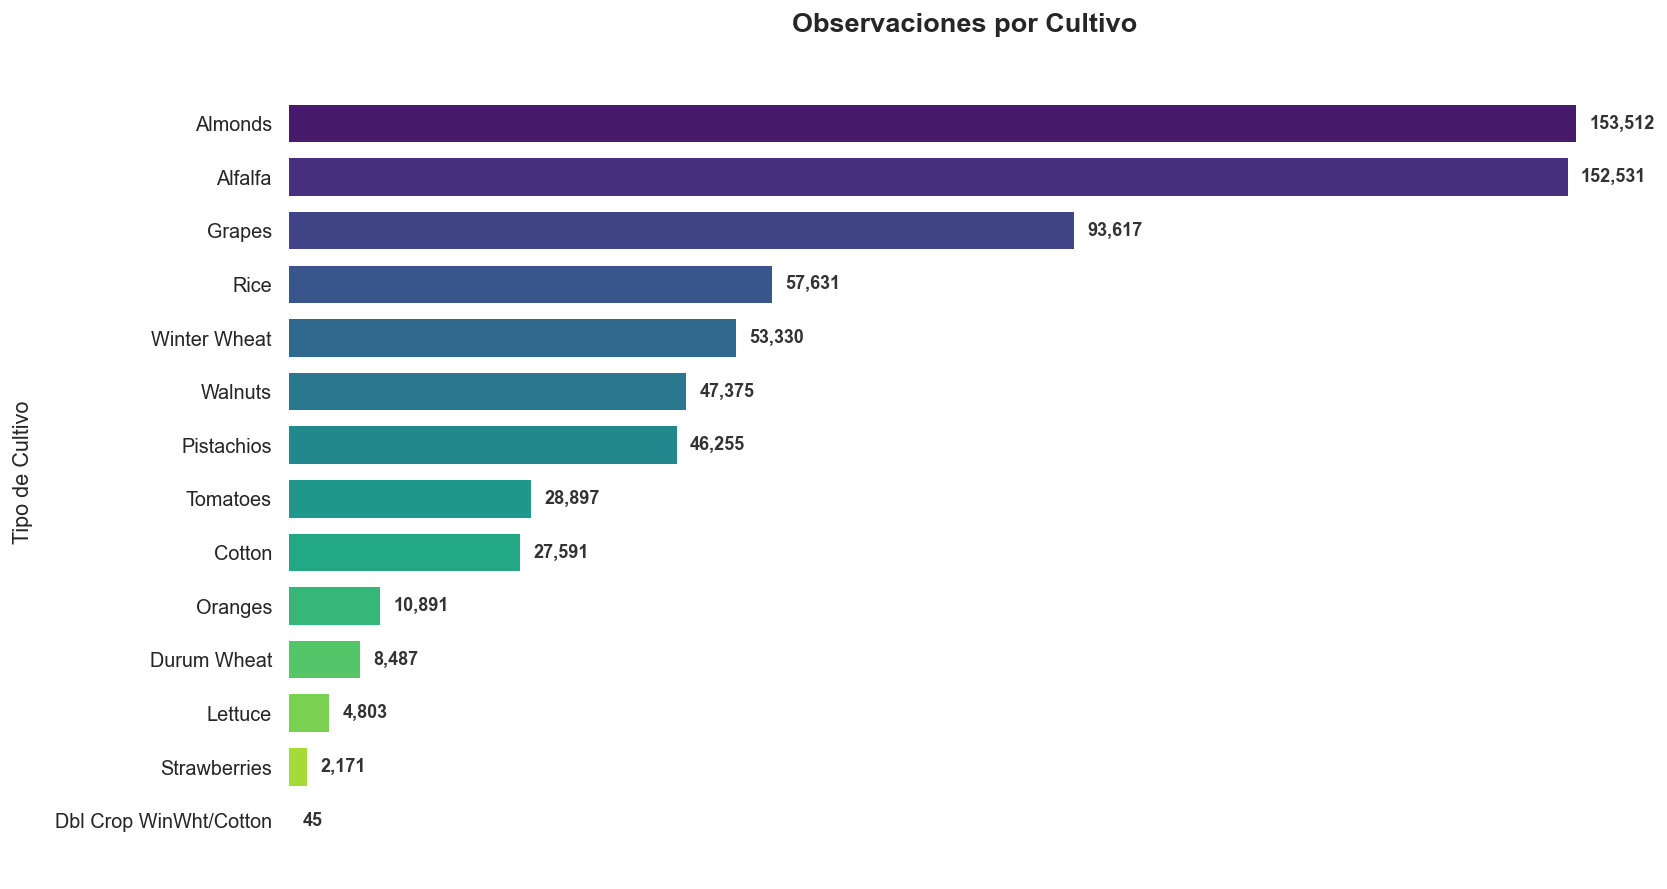

In [29]:
# Extraer los datos a listas 
cultivos = check_cultivos["crop_name"].to_list()
muestras = check_cultivos["Total Muestras"].to_list()

# Configurar el estilo 
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(13, 7))

# Crear el gráfico de barras horizontales
paleta = sns.color_palette("viridis", len(cultivos))
barras = ax.barh(cultivos, muestras, color=paleta, edgecolor="none", height=0.7)

# Invertimos el eje Y para que el cultivo con más muestras aparezca arriba del todo
ax.invert_yaxis()

# etiquetas de datos numéricos al final de cada barra para mejor legibilidad
max_valor = max(muestras)
for barra in barras:
    ancho = barra.get_width()
    ax.text(
        ancho + (max_valor * 0.01),  
        barra.get_y() + barra.get_height() / 2,
        f"{int(ancho):,}",           # Formato con separador de miles
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# títulos y etiquetas de los ejes 
ax.set_title("Observaciones por Cultivo", fontsize=15, fontweight="bold", pad=20)
ax.set_ylabel("Tipo de Cultivo", fontsize=12, labelpad=12)

ax.set_xticks([]) # Quitar las marcas del eje X
ax.set_xticklabels([]) # Quitar los números del eje X
ax.spines['bottom'].set_visible(False) # Quitar la línea inferior del eje
# Desactivar las líneas sobrantes del recuadro
sns.despine(left=True, bottom=True)

# Ajustar los márgenes automáticamente para evitar que se trunquen las etiquetas
plt.tight_layout()

# Mostrar el gráfico
plt.show()

El análisis de frecuencias muestra que existe desbalance en las clases de cultivos en el dataset, esto es normal debido  los patrones reales de ocupación del suelo en el Valle Central de California. La distribución está dominada por Almonds (153,512 observaciones) y Alfalfa (152,531 observaciones), los cuales acumulan cerca del 50% del total de datos. En el extremo opuesto se ubican cultivos con menor cantidad de observaciones como Lettuce (4,803) y Strawberries (2,171), además de la categoría marginal híbrida Dbl Crop WinWht/Cotton con apenas 45 registros. 

Este desbalance de clases implica que se podríamos tener sesgo en los modelos de clasificiación van a saber clasificar muy bien los cultivos de almendra y alfalfa pero va a tener errores en los cultivos con menor clasificación. Por tanto se debe contemplar una estrategia que contrareste este problema, en este caso no nos sirve tecnicas como el SMOTE ya que podria alterar la realidad geográfica, en cambio, se pueden incluir funciones de perdida que penalicen mediante pesos balanceados y las metricas para los modelos no pueden basarse en el accuracy general sino que es más importante la matiz de confusión, el f1-score y el balanced accuracy

In [15]:
#Análisis de Missing values en el nuevo dataset 

# Calculamos el total de nulos por columna (mantiene los nombres originales de las variables)
total_nulos = df2.select(pl.all().null_count())

# Calculamos el porcentaje de nulos por columna
porcentaje_nulos = df2.select((pl.all().null_count() / pl.count() * 100).round(2))

# tabla nulos (Nombre | Total | %)
df2_nulls = pl.DataFrame({
    "Variable": df2.columns,
    "Total Nulos": total_nulos.row(0),
    "% Nulos": porcentaje_nulos.row(0)
}).sort("Total Nulos", descending=True)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(df2_nulls)

C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\3254772839.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  porcentaje_nulos = df2.select((pl.all().null_count() / pl.count() * 100).round(2))


Variable,Total Nulos,% Nulos
str,i64,f64
"""ecec_r""",678251,98.71
"""es_proyeccion""",621840,90.5
"""hurs_245""",621840,90.5
"""hurs_585""",621840,90.5
"""pr_245""",621840,90.5
"""pr_585""",621840,90.5
"""referencia_base""",621840,90.5
"""tmax_245""",621840,90.5
"""tmax_585""",621840,90.5


# Análisis temporal

C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\3507409690.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("Muestras"))


year,Muestras
i64,u32
2008,34366
2009,33685
2010,35224
2011,33090
2012,34643
2013,34030
2014,33894
2015,33490
2016,34715


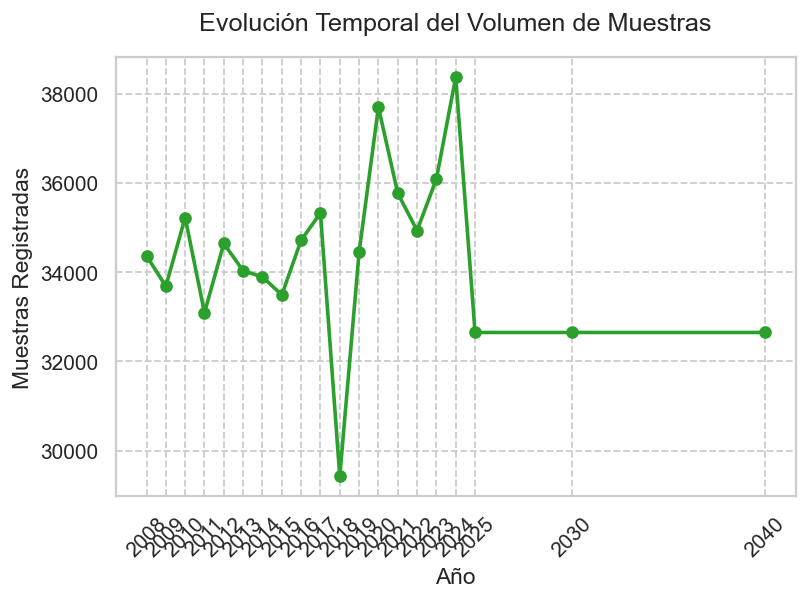

In [16]:
#Distribución de observaciones por Año

year_counts = (
    df2.group_by("year")
    .agg(pl.count().alias("Muestras"))
    .sort("year")
)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(year_counts)

# Gráfico de línea temporal
plt.plot(year_counts["year"], year_counts["Muestras"], marker='o', color='#2ca02c', linewidth=2)
plt.title("Evolución Temporal del Volumen de Muestras", fontsize=14, pad=15)
plt.xlabel("Año")
plt.ylabel("Muestras Registradas")
plt.xticks(year_counts["year"], rotation=45)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

### Datos historicos vs futuro

In [30]:
# Separar historico y futuro
HIST_YEARS = list(range(2008, 2026))
FUT_YEARS  = [2030, 2040]
TARGET_CROP_NAMES = ['Almonds','Grapes','Tomatoes','Cotton','Rice','Walnuts','Pistachios','Strawberries']

df_hist = df2.filter(pl.col('year').is_in(HIST_YEARS))
df_fut  = df2.filter(pl.col('year').is_in(FUT_YEARS))

print(f'Dataset limpio : {df2.shape[0]:>10,} filas x {df2.shape[1]} columnas')
print(f'Historico 2008-25: {df_hist.shape[0]:>10,} filas')
print(f'Futuro 2030/2040 : {df_fut.shape[0]:>10,} filas')
print(f'Cultivos unicos  : {df_hist["crop_name"].n_unique()}')
print(f'Anos historicos  : {sorted(df_hist["year"].unique().to_list())}')

Dataset limpio :    687,136 filas x 39 columnas
Historico 2008-25:    621,840 filas
Futuro 2030/2040 :     65,296 filas
Cultivos unicos  : 14
Anos historicos  : [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\755987335.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("cantidad"))


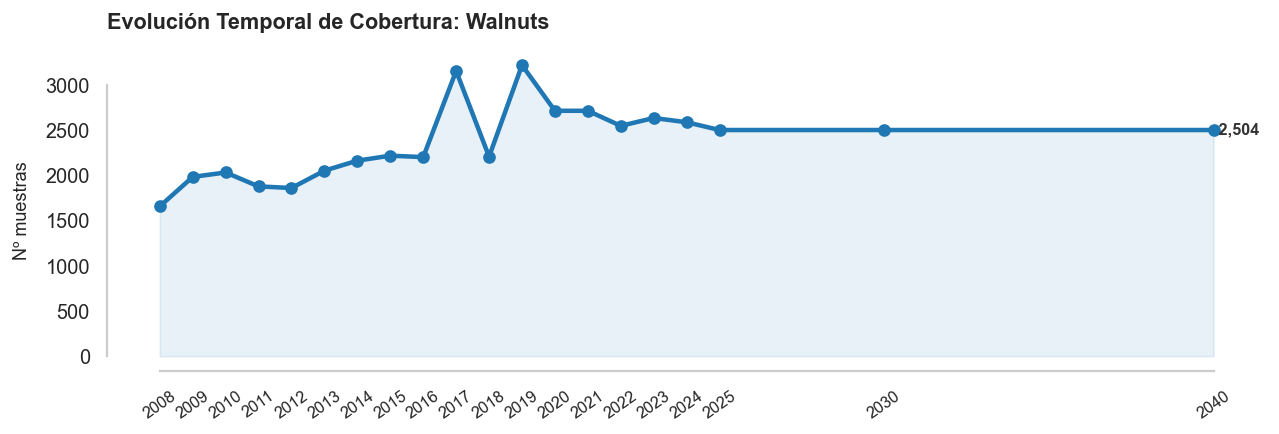

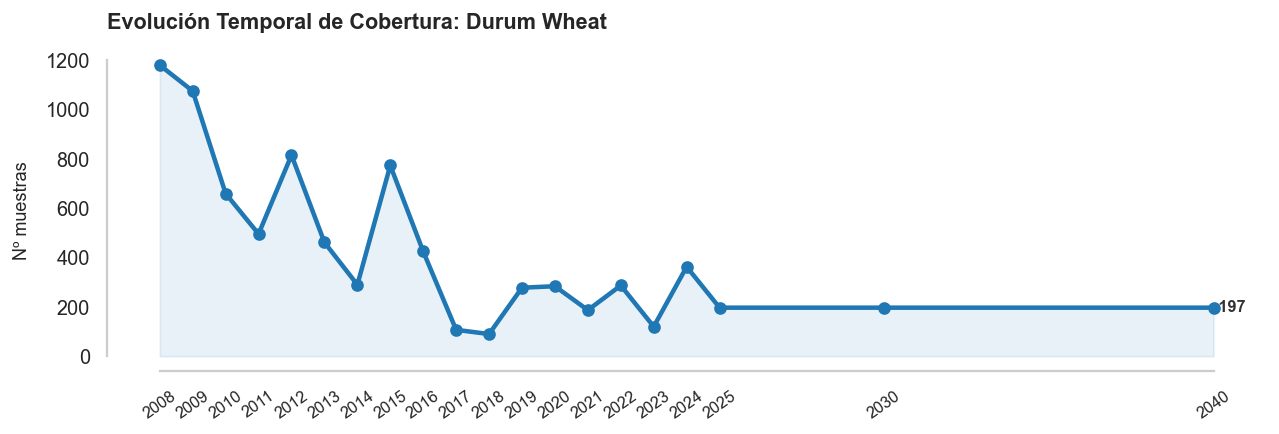

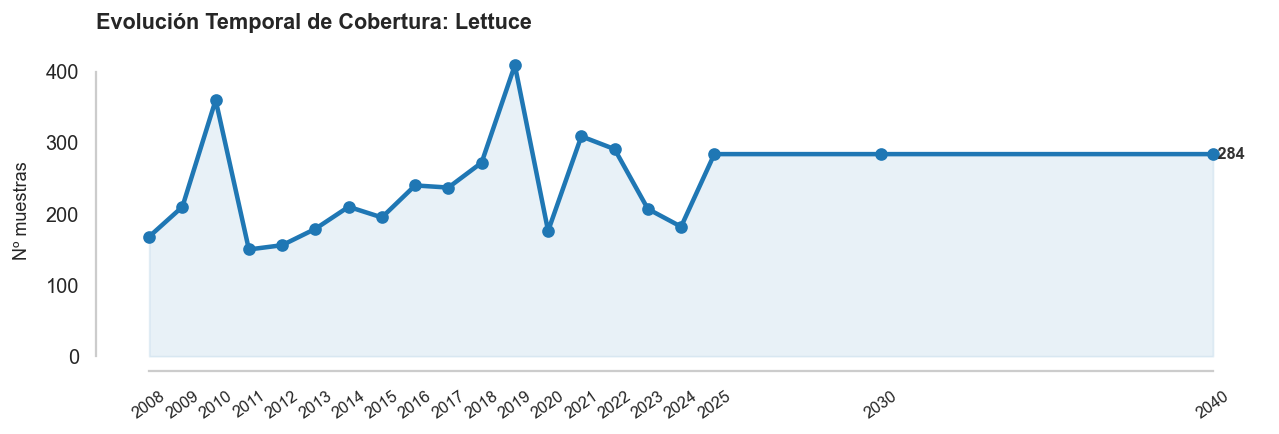

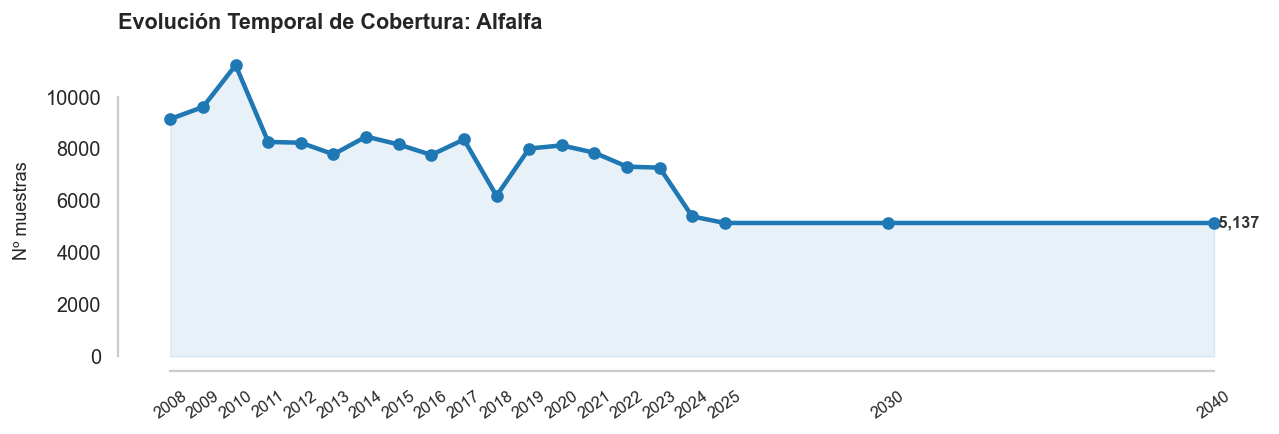

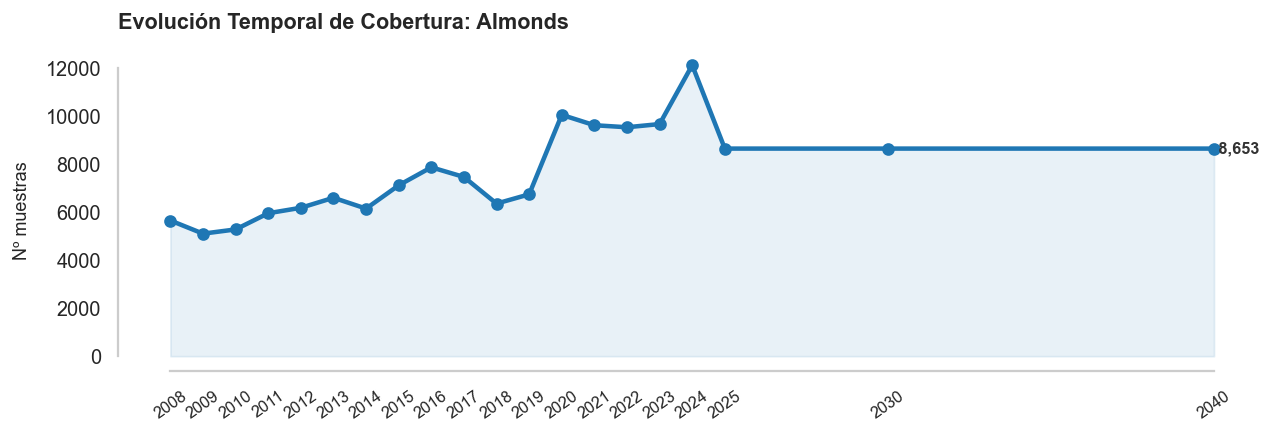

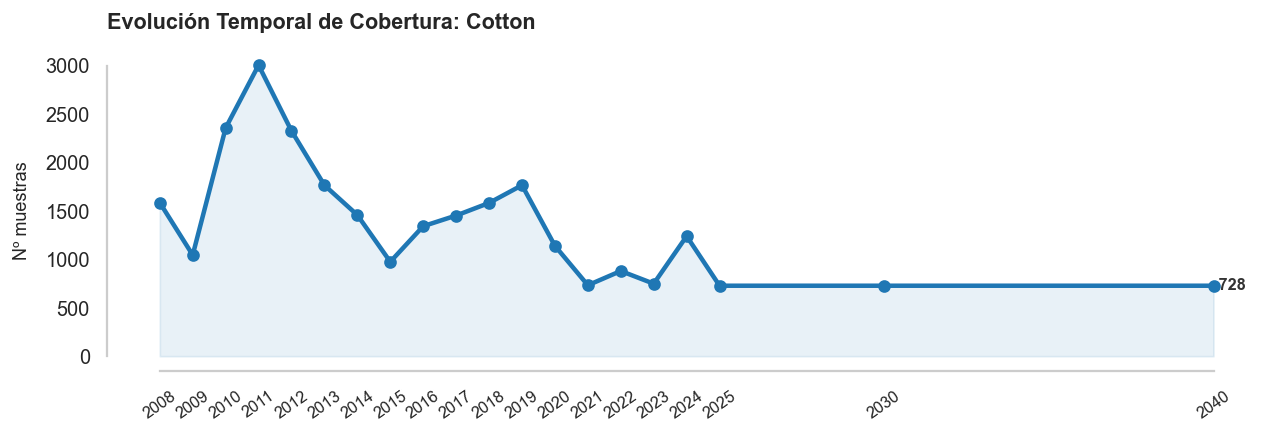

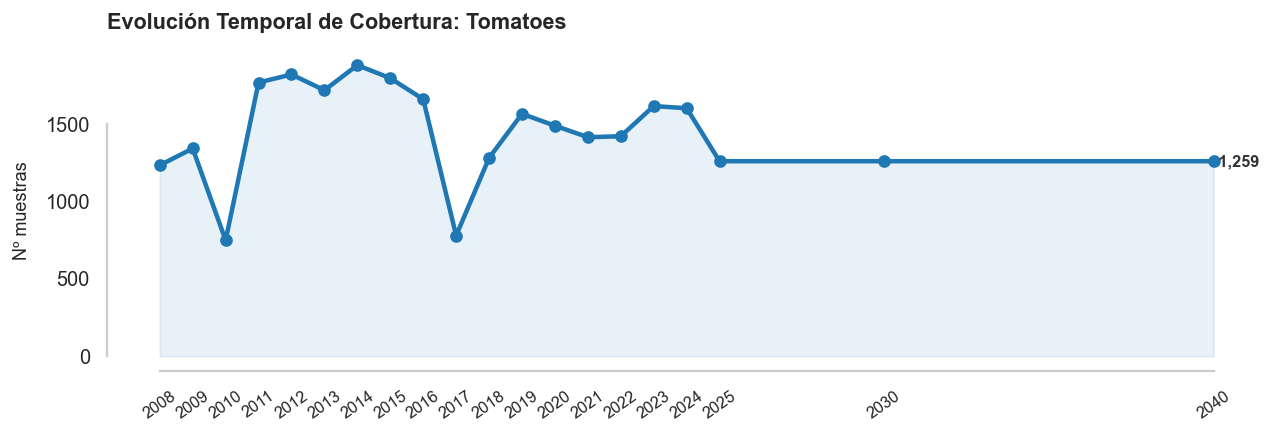

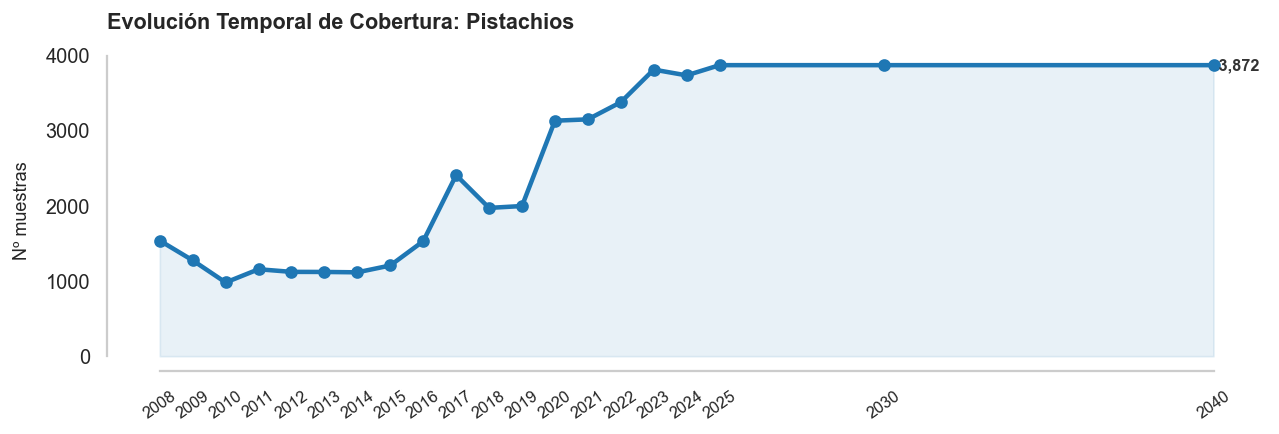

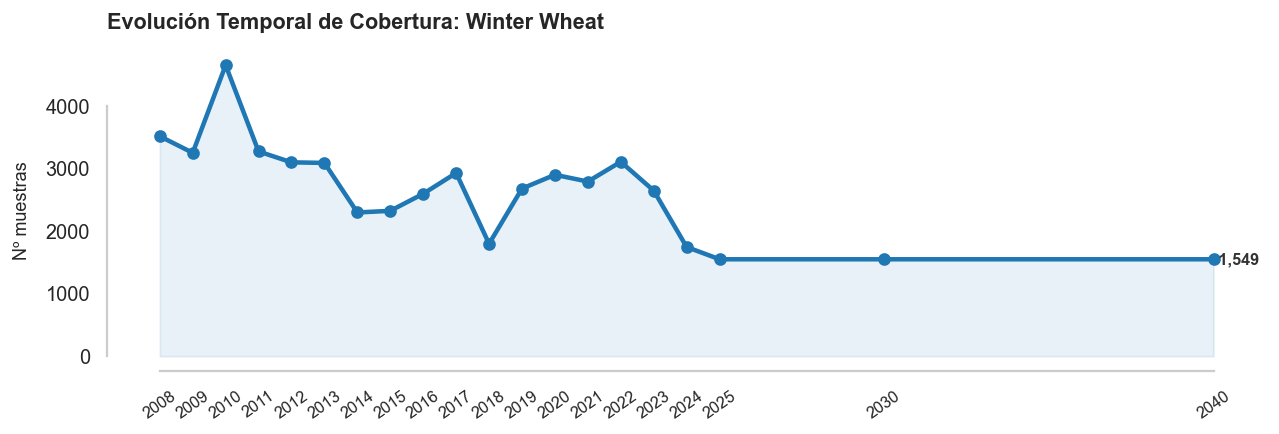

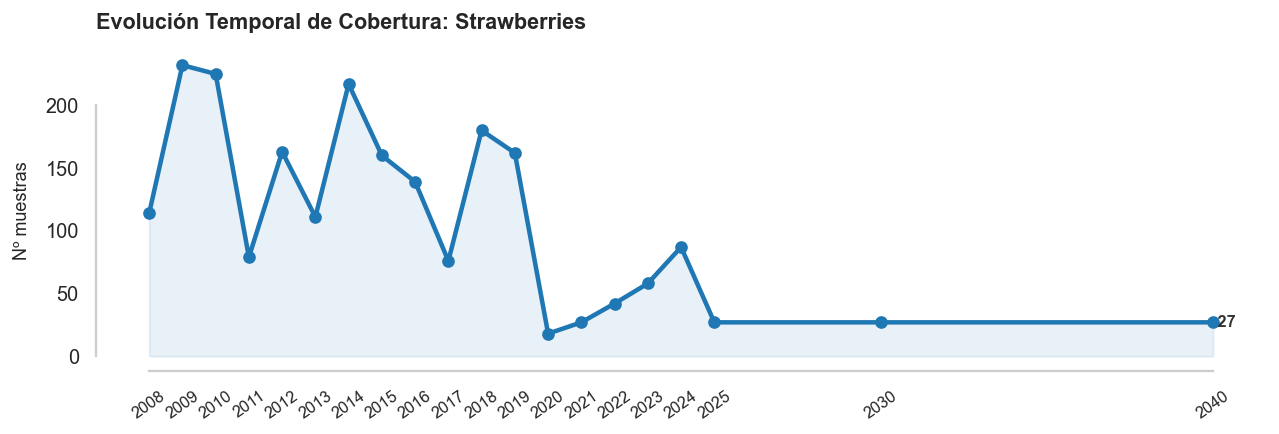

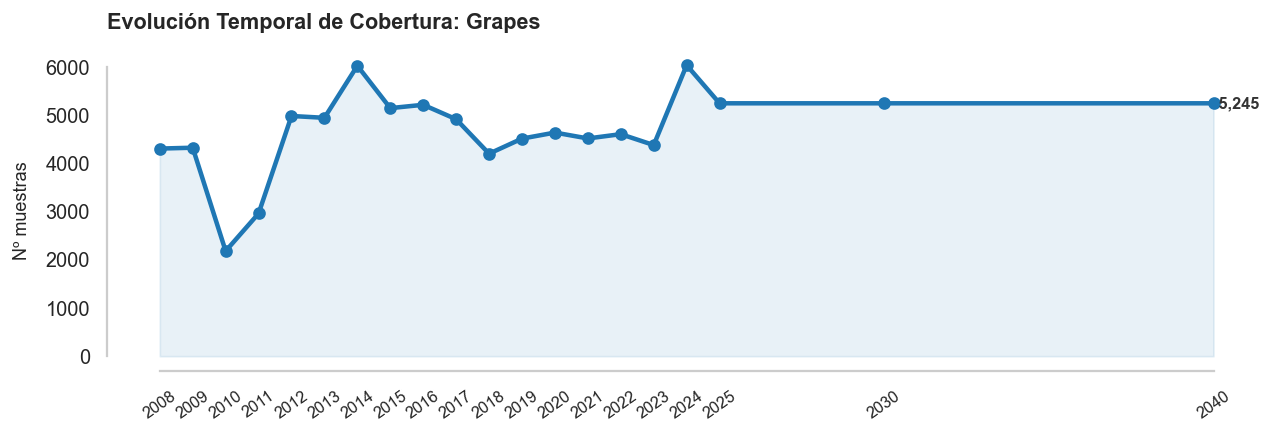

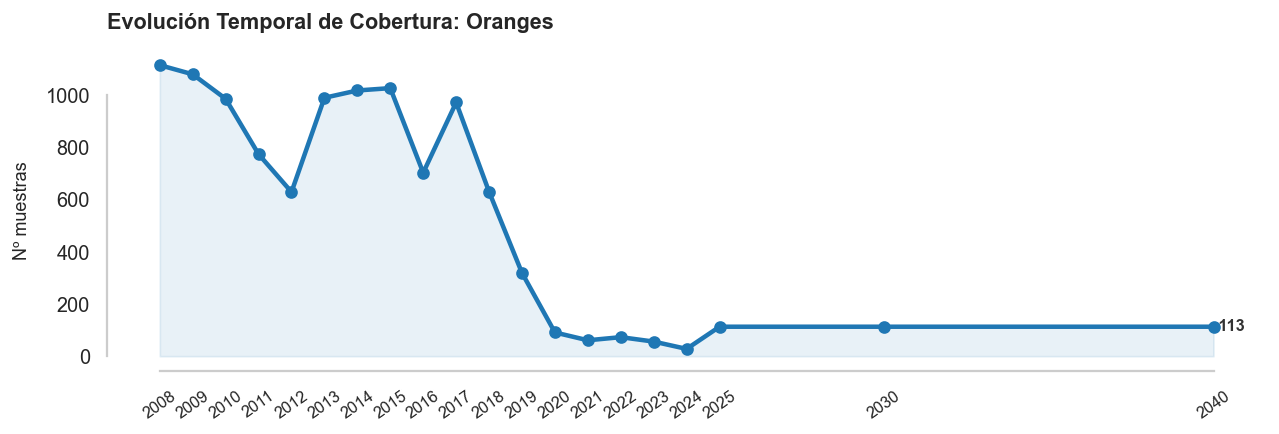

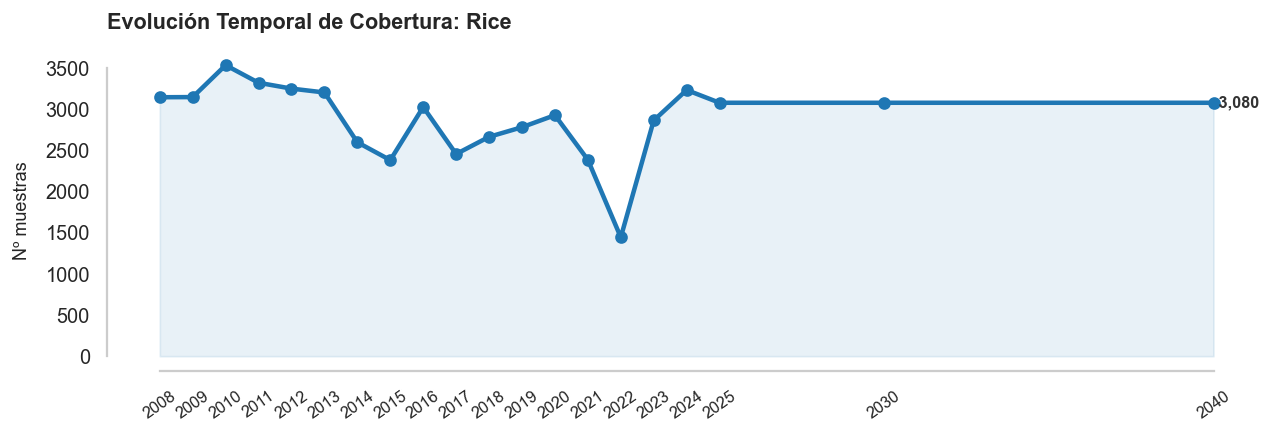

In [32]:
# 1. Agrupar por año y cultivo para calcular las frecuencias temporales
df_evolucion = (
    df2.group_by(["year", "crop_name"])
    .agg(pl.count().alias("cantidad"))
    .sort(["crop_name", "year"])
)

# 2. Obtener la lista única de cultivos (excluyendo el doble cultivo marginal si ya lo filtraste)
lista_cultivos = [c for c in df_evolucion["crop_name"].unique().to_list() if "Dbl Crop" not in c]

# 3. Bucle automatizado para renderizar una gráfica independiente por cultivo
for cultivo in lista_cultivos:
    
    # Filtrar los datos específicos del cultivo actual
    df_crop = df_evolucion.filter(pl.col("crop_name") == cultivo)
    
    # Extraer los ejes a listas nativas de Python para el motor gráfico
    anos = df_crop["year"].to_list()
    cantidades = df_crop["cantidad"].to_list()
    
    # Configurar lienzo minimalista (estilo 'white' sin grid de fondo)
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(10, 3.5))
    
    # Dibujar la línea de tendencia y los marcadores de los puntos anuales
    # Usamos una tonalidad azul-verdosa corporativa consistente con la paleta previa
    ax.plot(anos, cantidades, color="#1f77b4", linewidth=2.5, marker="o", markersize=6, label=cultivo)
    
    # Rellenar sutilmente el área bajo la curva para darle cuerpo visual (Opcional, estilo elegante)
    ax.fill_between(anos, cantidades, color="#1f77b4", alpha=0.1)
    
    # Personalización de títulos y etiquetas individuales
    ax.set_title(f"Evolución Temporal de Cobertura: {cultivo}", fontsize=12, fontweight="bold", loc="left", pad=12)
    ax.set_ylabel("Nº muestras", fontsize=10, labelpad=8)
    
    # Forzar a que el eje X muestre los años de forma limpia y entera (evita decimales flotantes)
    ax.set_xticks(anos)
    ax.set_xticklabels([str(int(a)) for a in anos], rotation=35, fontsize=9)
    
    # Resaltar el valor del último año disponible colocando una etiqueta de datos de cierre
    if len(cantidades) > 0:
        ax.text(
            anos[-1], cantidades[-1], f" {int(cantidades[-1]):,}", 
            fontsize=9, fontweight="bold", color="#333333", va="center", ha="left"
        )
    
    # Optimización del Data-Ink Ratio: remover recuadros sobrantes
    sns.despine(left=False, bottom=False, trim=True)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    
    # Ajustar márgenes para que no se corten los títulos
    plt.tight_layout()
    
    # Mostrar la gráfica actual antes de pasar a la siguiente iteración del bucle
    plt.show()

# Varibles de Clima

In [38]:
# Filtramos cuáles variables del diccionario de utils existen en las columnas reales
clima = [c for c in HIST_CLIM_VARS if c in df_hist.columns]

# Calculamos las estadísticas descriptivas vectorizadas en Polars
stats = df_hist.select(clima).describe()

# Creación de un diccionario de renombre dinámico
mapa_nombres = {
    col: f"{meta['name']} ({meta['unit']})" 
    for col, meta in HIST_CLIM_VARS.items() if col in stats.columns
}

# Renombramos las columnas de la tabla de estadísticas de golpe
stats = stats.rename(mapa_nombres)

with pl.Config(tbl_cols=-1, float_precision=2):
    display(stats)

statistic,Precipitacion Anual (mm),Temperatura Media (°C),Temperatura Maxima Media (°C),Temperatura Minima Media (°C),VPD Maximo (hPa),VPD Minimo (hPa)
str,f64,f64,f64,f64,f64,f64
"""count""",621840.00,621840.00,621840.00,621840.00,621840.00,621840.00
"""null_count""",0.00,0.00,0.00,0.00,0.00,0.00
"""mean""",300.33,16.93,24.54,9.33,24.66,2.94
"""std""",197.32,2.73,2.71,2.90,5.22,1.68
"""min""",11.54,-0.40,5.36,-6.15,2.08,0.07
"""25%""",159.13,16.31,23.64,8.81,21.80,1.86
"""50%""",252.65,17.15,24.67,9.63,24.13,2.51
"""75%""",395.69,17.92,25.60,10.42,26.49,3.49
"""max""",2939.65,25.71,33.05,20.03,50.04,15.61


ValueError: too many values to unpack (expected 2)

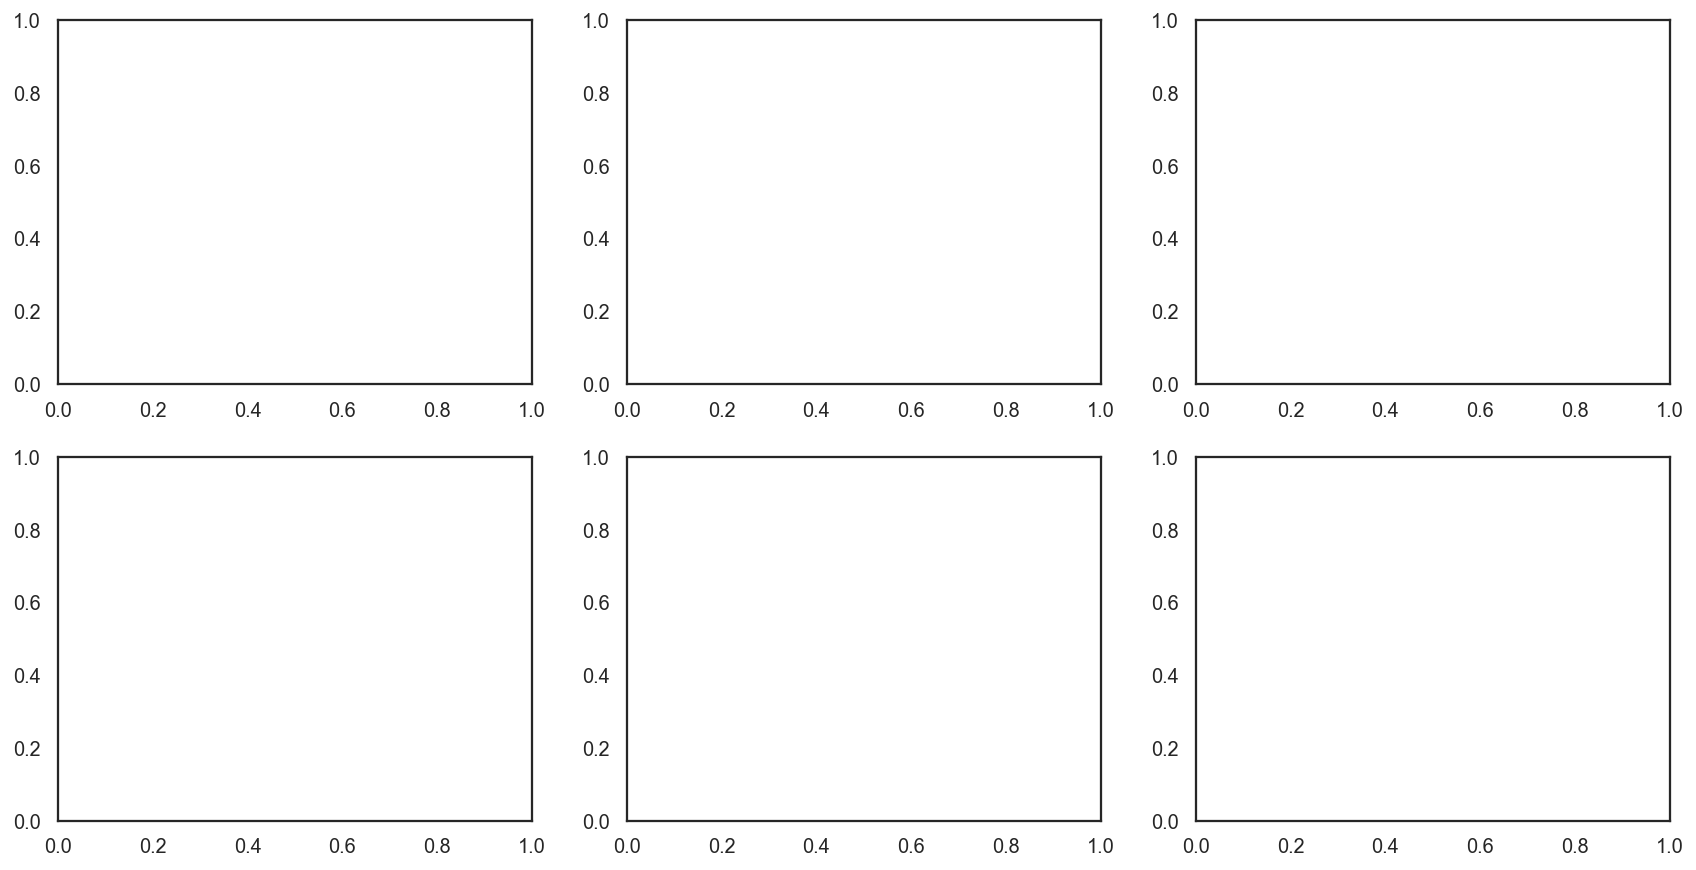

In [42]:
# Histogramas con KDE
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors = sns.color_palette('husl', len(clima))

for i, col in enumerate(clima):
    ax   = axes[i]
    data = df_hist[col].drop_nulls().to_numpy()
    label, unit = mapa_nombres[col]
    ax.hist(data, bins=60, color=colors[i], alpha=0.75, edgecolor='white', lw=0.3)
    ax.axvline(float(df_hist[col].median()), color='black', lw=1.5,
               linestyle='--', label=f'Mediana: {float(df_hist[col].median()):.1f}')
    ax.set_title(f'{label} ({unit})', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Distribucion de variables climaticas historicas (2008-2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'06_hist_clima.png'), bbox_inches='tight')
plt.show()

# Histogramas con KDE
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors = sns.color_palette('husl', len(clim_exist))

for i, col in enumerate(clim_exist):
    ax   = axes[i]
    data = df_hist[col].drop_nulls().to_numpy()
    label, unit = CLIM_META[col]
    ax.hist(data, bins=60, color=colors[i], alpha=0.75, edgecolor='white', lw=0.3)
    ax.axvline(float(df_hist[col].median()), color='black', lw=1.5,
               linestyle='--', label=f'Mediana: {float(df_hist[col].median()):.1f}')
    ax.set_title(f'{label} ({unit})', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Distribucion de variables climaticas historicas (2008-2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'06_hist_clima.png'), bbox_inches='tight')
plt.show()

# Variables de Suelo

In [18]:
# Resumen Estadístico de las Propiedades Edáficas:

# Seleccionamos las variables numéricas clave de suelos
soil_cols = [
    "claytotal_r", "sandtotal_r", "silttotal_r", 
    "om_r", "ph1to1h2o_r", "awc_r", "profundidad_efectiva_cm"
]

# Filtramos solo las columnas que existan en tu DF y calculamos el resumen
existing_soil_cols = [col for col in soil_cols if col in df2.columns]
display(df2.select(existing_soil_cols).describe())

statistic,claytotal_r,sandtotal_r,silttotal_r,om_r,ph1to1h2o_r,awc_r,profundidad_efectiva_cm
str,f64,f64,f64,f64,f64,f64,f64
"""count""",687136.0,687136.0,687136.0,687136.0,687136.0,687136.0,687136.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",25.175032,42.591461,32.061894,1.741025,7.356365,0.140442,29.338827
"""std""",15.37453,23.819398,13.804733,3.428795,0.814752,0.040609,18.40128
"""min""",0.0,0.0,0.0,0.0,4.0,0.0,1.0
"""25%""",13.0,22.1,19.6,0.75,6.7,0.12,16.0
"""50%""",21.0,39.799999,31.700001,1.25,7.5,0.14,25.0
"""75%""",33.0,67.199997,40.0,2.0,8.0,0.16,38.0
"""max""",70.0,98.900002,85.699997,100.0,9.8,0.6,203.0


C:\Users\lesli\AppData\Local\Temp\ipykernel_6500\3777658780.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


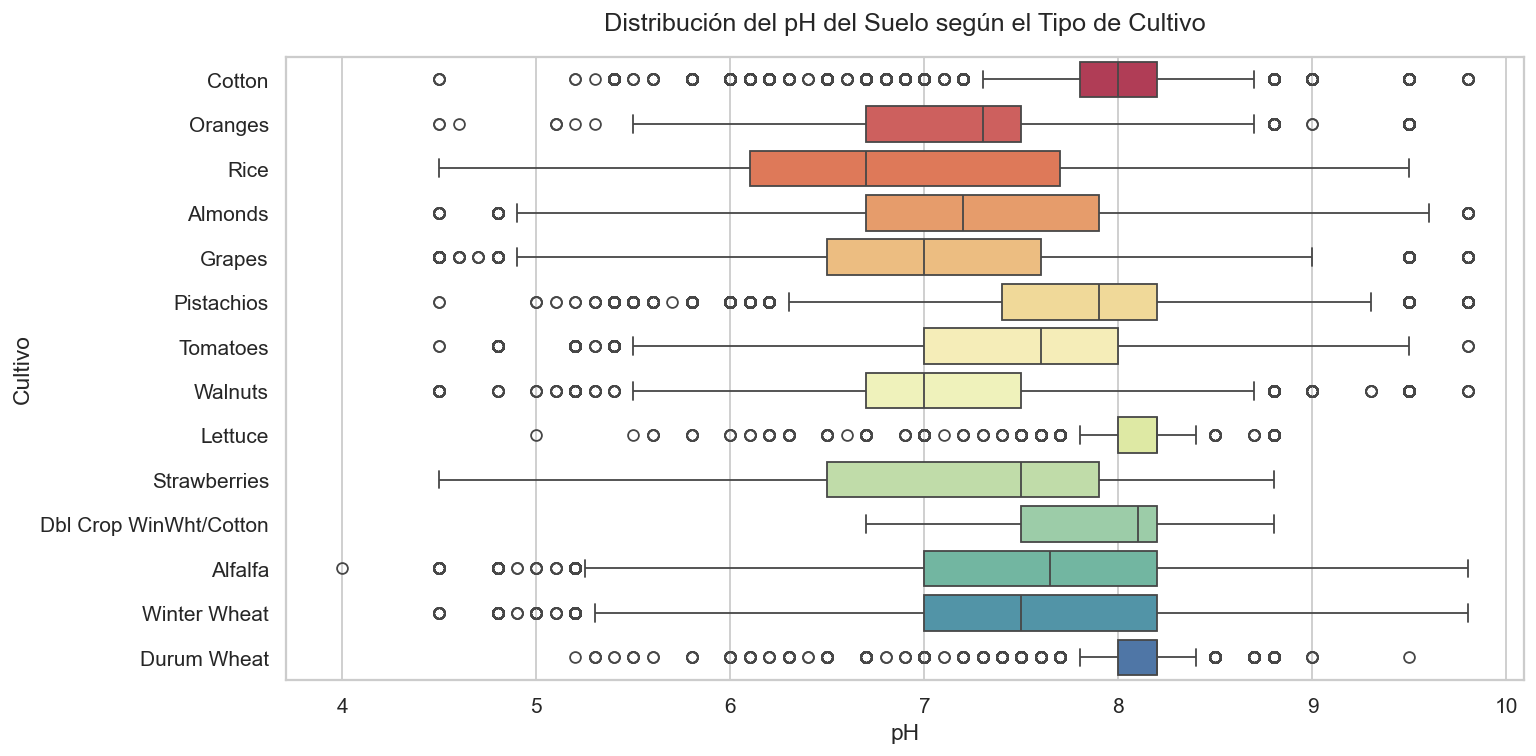

In [19]:
if "ph1to1h2o_r" in df2.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df2.select(["crop_name", "ph1to1h2o_r"]).to_pandas(),
        x="ph1to1h2o_r",
        y="crop_name",
        palette="Spectral"
    )
    plt.title("Distribución del pH del Suelo según el Tipo de Cultivo", fontsize=14, pad=15)
    plt.xlabel("pH")
    plt.ylabel("Cultivo")
    plt.tight_layout()
    plt.show()